# Phase 1 延伸 — 滾動時間窗分析

**動機**：全期（1,807 期）均無訊號。但若存在局部短暫結構（如機台老化、換球週期），可能在短窗口才看得到。

**三條分析線**：
1. **Mann-Kendall 趨勢檢定**：各號碼出現頻率是否有長期單調趨勢？
2. **時段切割比較**：前中後各 600 期的 transition Test B，看訊號是否在特定年代出現
3. **50 期滾動頻率圖**：視覺追蹤各號碼的短期頻率波動，找局部高峰

## 1. 載入資料 & 建時間序列矩陣

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,
})

conn = sqlite3.connect(Path("lottery.db"))
df = pd.read_sql(
    "SELECT draw_date, n1,n2,n3,n4,n5,n6 FROM draws WHERE split='train' ORDER BY id",
    conn,
    parse_dates={"draw_date": {"format": "%Y/%m/%d"}},
)
conn.close()

Z1 = ["n1","n2","n3","n4","n5","n6"]
N  = len(df)
draws = [set(row) for row in df[Z1].itertuples(index=False, name=None)]

# 建 presence matrix：shape (N, 38)，presence[t, x-1] = 1 if x in draw t
presence = np.zeros((N, 38), dtype=np.int8)
for t, s in enumerate(draws):
    for x in s:
        presence[t, x - 1] = 1

print(f"訓練期數：{N}")
print(f"presence matrix shape：{presence.shape}")
print(f"日期範圍：{df.draw_date.min().date()} ～ {df.draw_date.max().date()}")

訓練期數：1807
presence matrix shape：(1807, 38)
日期範圍：2008-01-24 ～ 2025-05-15


## 2. Mann-Kendall 趨勢檢定

每個號碼每 50 期為一段，計算各段出現率，再做 MK 趨勢檢定。  
H₀：無單調趨勢。顯著 → 該號碼頻率長期在漲或跌。

Mann-Kendall（36 段 × 50 期）
FDR q<0.05：0 / 38 個號碼

        tau       p    q_bh
num                        
37  -0.2656  0.0287  0.4966
21   0.2516  0.0388  0.4966
2    0.2492  0.0413  0.4966
31   0.2359  0.0523  0.4966
17   0.2025  0.0939  0.6874
6   -0.1996  0.1085  0.6874
24  -0.1787  0.1412  0.7533
10  -0.1626  0.1810  0.7533
5   -0.1600  0.1934  0.7533
9    0.1513  0.2180  0.7533


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_4176\2099846051.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_4176\2099846051.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


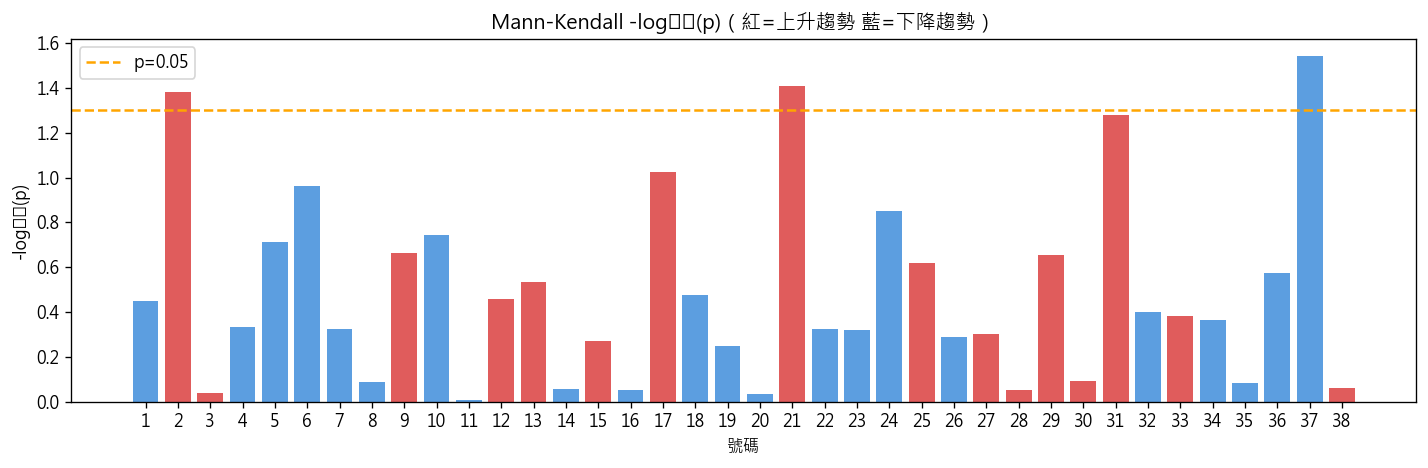

In [2]:
BLOCK = 50   # 每段期數

def mannkendall(x):
    """回傳 (tau, p-value)，以 scipy.stats.kendalltau 對 (rank, x) 做檢定。"""
    n = len(x)
    tau, p = stats.kendalltau(np.arange(n), x)
    return tau, p

# 每個號碼切段
n_blocks = N // BLOCK
mk_results = []
for num in range(1, 39):
    series = [presence[i*BLOCK:(i+1)*BLOCK, num-1].mean() for i in range(n_blocks)]
    tau, p = mannkendall(series)
    mk_results.append({"num": num, "tau": tau, "p": p})

mk_df = pd.DataFrame(mk_results).set_index("num")
_, q_mk, _, _ = multipletests(mk_df["p"].values, method="fdr_bh")
mk_df["q_bh"] = q_mk
sig_mk = mk_df[mk_df["q_bh"] < 0.05]

print(f"Mann-Kendall（{n_blocks} 段 × {BLOCK} 期）")
print(f"FDR q<0.05：{len(sig_mk)} / 38 個號碼")
print()
print(mk_df.sort_values("p").head(10).round(4))

# 視覺：volcano plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["#e05c5c" if tau > 0 else "#5c9ee0" for tau in mk_df["tau"]]
ax.bar(mk_df.index, -np.log10(mk_df["p"]), color=colors)
ax.axhline(-np.log10(0.05), color="orange", linestyle="--", label="p=0.05")
ax.set_title(f"Mann-Kendall -log₁₀(p)（紅=上升趨勢 藍=下降趨勢）")
ax.set_xlabel("號碼")
ax.set_ylabel("-log₁₀(p)")
ax.set_xticks(range(1, 39))
ax.legend()
plt.tight_layout()
plt.show()

## 3. 時段切割：前 / 中 / 後三期的 Transition Test B

In [3]:
def testB_on_slice(draw_slice: list[set]) -> pd.DataFrame:
    """給定連續期的 draws，跑 lag-1 Test B，回傳各號碼 p-value。"""
    n = len(draw_slice)
    rows = []
    for x in range(1, 39):
        row_counts = np.zeros(38, dtype=int)
        for t in range(n - 1):
            if x in draw_slice[t]:
                for y in draw_slice[t + 1]:
                    row_counts[y - 1] += 1
        total = row_counts.sum()
        if total == 0:
            continue
        chi2, p = stats.chisquare(row_counts, f_exp=np.full(38, total / 38))
        rows.append({"x": x, "chi2": chi2, "p": p, "n_periods": n})
    return pd.DataFrame(rows).set_index("x")

# 三等分
third = N // 3
slices = {
    f"前段（期 1–{third}）":        draws[:third],
    f"中段（期 {third+1}–{2*third}）": draws[third:2*third],
    f"後段（期 {2*third+1}–{N}）":   draws[2*third:],
}
# 另加近 200 期
slices[f"近 200 期（期 {N-200+1}–{N}）"] = draws[N-200:]

slice_results = {}
for label, sl in slices.items():
    res = testB_on_slice(sl)
    _, q, _, _ = multipletests(res["p"].values, method="fdr_bh")
    res["q_bh"] = q
    sig_raw = (res["p"] < 0.05).sum()
    sig_fdr = (res["q_bh"] < 0.05).sum()
    slice_results[label] = res
    print(f"{label}：{len(sl)} 期 | Test B 原始p<0.05：{sig_raw}/38 | FDR q<0.05：{sig_fdr}/38")

前段（期 1–602）：602 期 | Test B 原始p<0.05：0/38 | FDR q<0.05：0/38
中段（期 603–1204）：602 期 | Test B 原始p<0.05：0/38 | FDR q<0.05：0/38
後段（期 1205–1807）：603 期 | Test B 原始p<0.05：0/38 | FDR q<0.05：0/38
近 200 期（期 1608–1807）：200 期 | Test B 原始p<0.05：0/38 | FDR q<0.05：0/38


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_4176\782231556.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_4176\782231556.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()


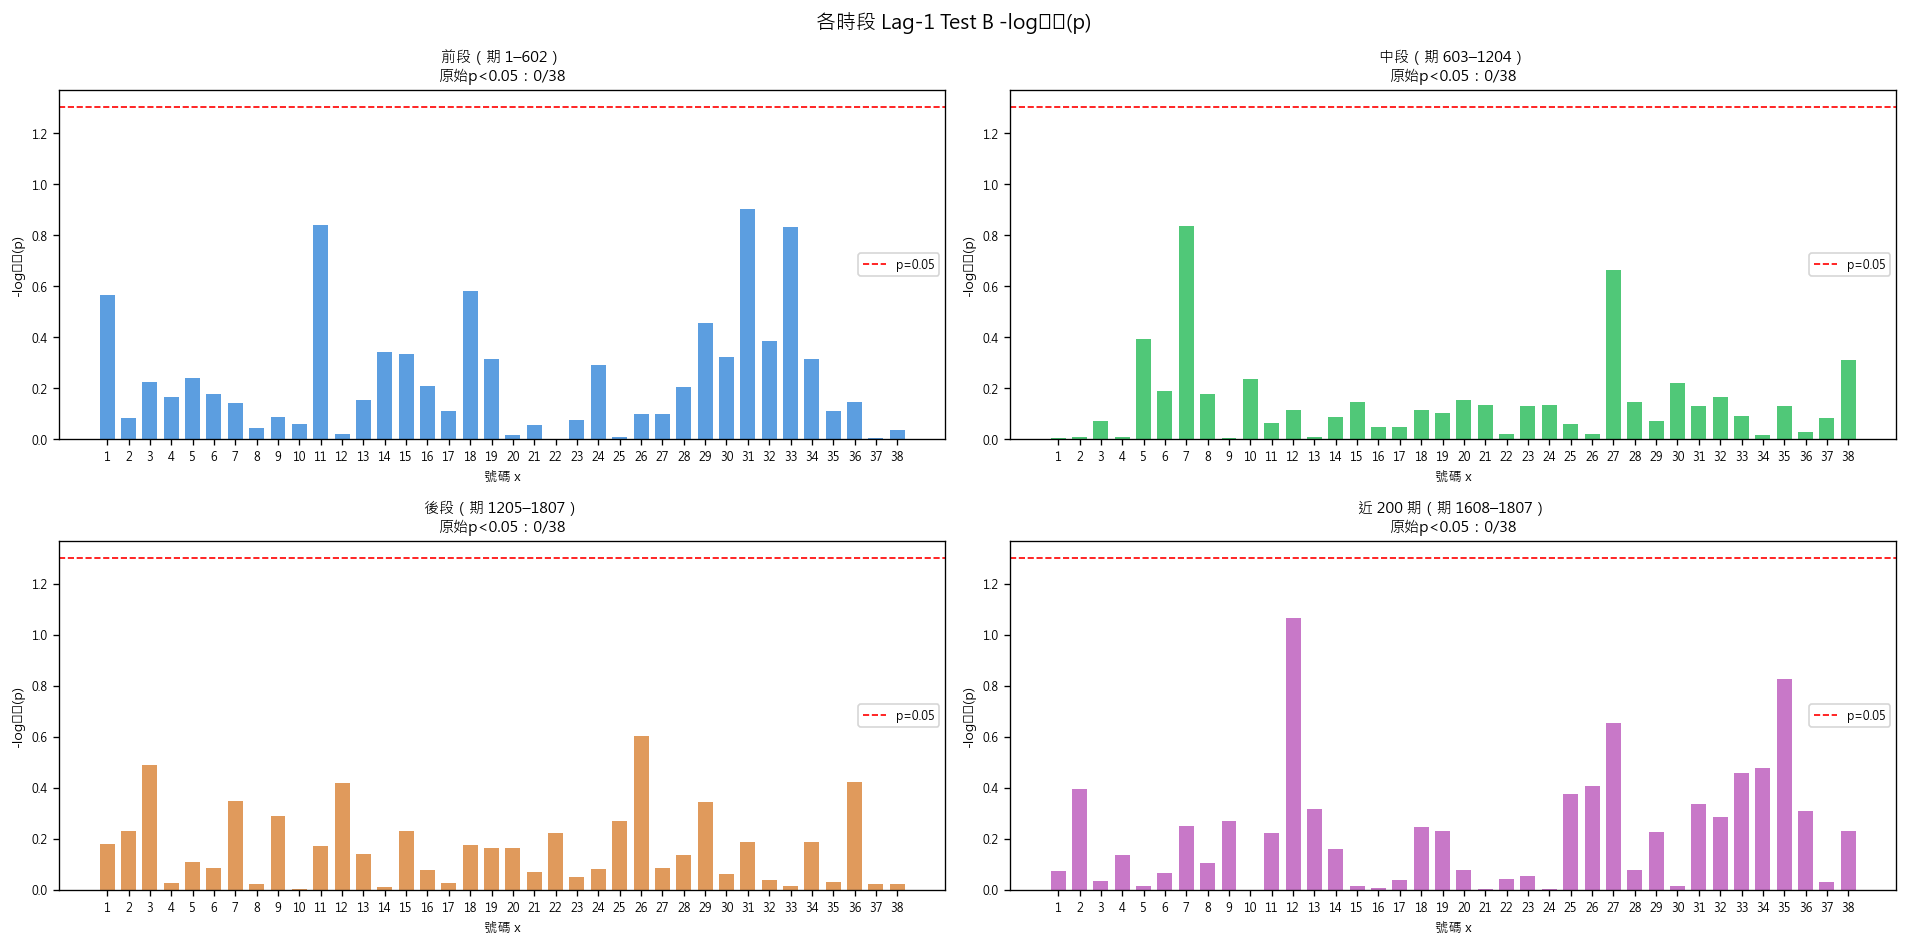

In [4]:
# 四個時段 -log10(p) 並列
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
palette = ["#5c9ee0", "#50c878", "#e09a5c", "#c878c8"]

for ax, (label, res), color in zip(axes.flat, slice_results.items(), palette):
    ax.bar(res.index, -np.log10(res["p"]), color=color, width=0.7)
    ax.axhline(-np.log10(0.05), color="red", linestyle="--", linewidth=1, label="p=0.05")
    n_raw = (res["p"] < 0.05).sum()
    ax.set_title(f"{label}\n原始p<0.05：{n_raw}/38", fontsize=9)
    ax.set_xlabel("號碼 x", fontsize=8)
    ax.set_ylabel("-log₁₀(p)", fontsize=8)
    ax.set_xticks(range(1, 39))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

plt.suptitle("各時段 Lag-1 Test B -log₁₀(p)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. 50 期滾動頻率圖（近期最極端的號碼）

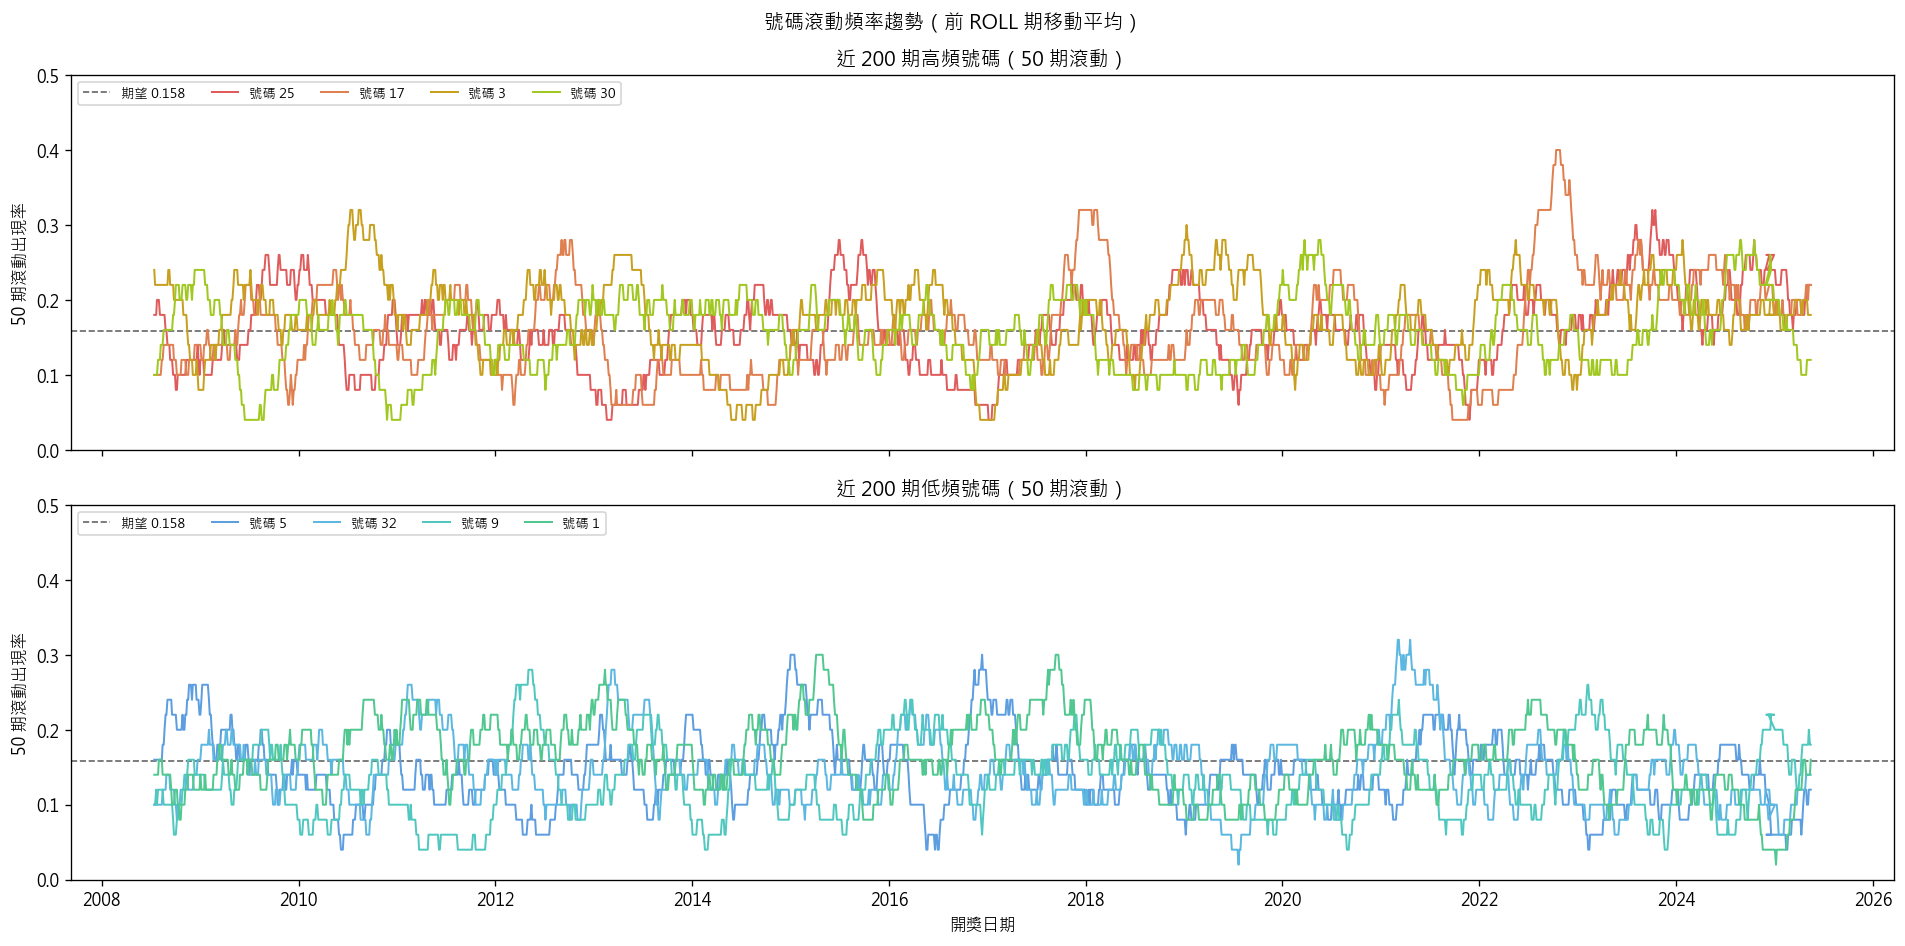

近 200 期平均出現率（50 期滾動均值）：
  高頻： {25: '0.226', 17: '0.213', 3: '0.196', 30: '0.190'}
  低頻： {1: '0.123', 9: '0.123', 32: '0.122', 5: '0.115'}
期望值：0.158


In [5]:
ROLL = 50
# 計算每個號碼的 50 期滾動出現率
pres_df = pd.DataFrame(presence, columns=range(1, 39), index=df["draw_date"])
roll_freq = pres_df.rolling(ROLL).mean()  # shape (N, 38)

expected = 6 / 38  # 理論期望出現率

# 找近 200 期最偏離的 8 個號碼（最高與最低各 4）
recent_mean = roll_freq.iloc[-200:].mean()
top4  = recent_mean.nlargest(4).index.tolist()
bot4  = recent_mean.nsmallest(4).index.tolist()
highlight = top4 + bot4

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, nums, title, color_list in [
    (axes[0], top4,  "近 200 期高頻號碼（50 期滾動）",
     ["#e05c5c","#e08050","#c8a020","#a0c820"]),
    (axes[1], bot4,  "近 200 期低頻號碼（50 期滾動）",
     ["#5c9ee0","#5cb8e0","#50c8c0","#50c890"]),
]:
    ax.axhline(expected, color="black", linestyle="--", linewidth=1,
               label=f"期望 {expected:.3f}", alpha=0.6)
    for num, c in zip(nums, color_list):
        ax.plot(roll_freq.index, roll_freq[num], label=f"號碼 {num}", color=c, linewidth=1.2)
    ax.set_title(title)
    ax.set_ylabel("50 期滾動出現率")
    ax.legend(loc="upper left", fontsize=8, ncol=5)
    ax.set_ylim(0, 0.5)

axes[1].set_xlabel("開獎日期")
plt.suptitle("號碼滾動頻率趨勢（前 ROLL 期移動平均）", fontsize=12)
plt.tight_layout()
plt.show()

# 近 200 期排行
recent_rank = recent_mean.sort_values(ascending=False)
print("近 200 期平均出現率（50 期滾動均值）：")
print(f"{'高頻':>4}：", {n: f"{v:.3f}" for n, v in recent_rank.head(4).items()})
print(f"{'低頻':>4}：", {n: f"{v:.3f}" for n, v in recent_rank.tail(4).items()})
print(f"期望值：{expected:.3f}")

## 5. 近 200 期 Binomial Test（近期高/低頻是否統計顯著）

近 200 期靜態頻率 binomial test（n=200, p₀=0.1579）
FDR q<0.05：0 / 38

      k  obs_rate    lift   p_raw    q_bh
num                                      
17   45     0.225  1.4250  0.0116  0.4410
25   43     0.215  1.3617  0.0324  0.6160
34   22     0.110  0.6967  0.0653  0.8267
12   23     0.115  0.7283  0.0996  0.9176
3    39     0.195  1.2350  0.1466  0.9176
29   38     0.190  1.2033  0.2080  0.9176
6    25     0.125  0.7917  0.2438  0.9176
19   25     0.125  0.7917  0.2438  0.9176
32   25     0.125  0.7917  0.2438  0.9176
5    25     0.125  0.7917  0.2438  0.9176


C:\Users\frodo.MSI\AppData\Local\Temp\ipykernel_4176\955837942.py:42: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout()
C:\Users\frodo.MSI\OneDrive\Desktop\lottery-ticket\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


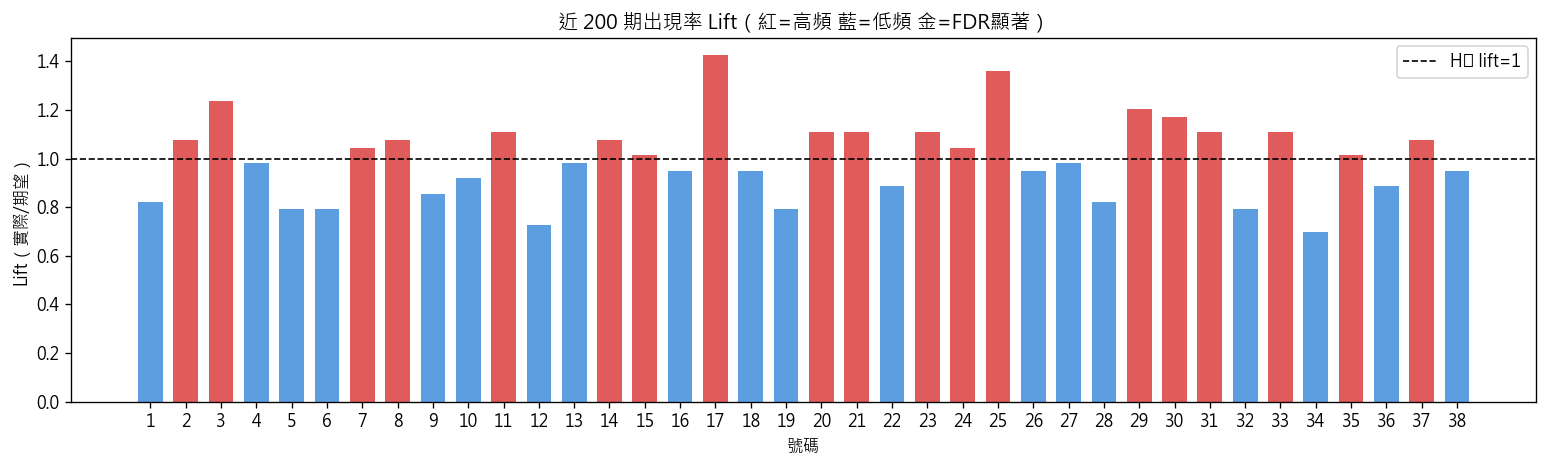

In [6]:
# 近 200 期每個號碼的靜態頻率 binomial test
recent_200 = presence[-200:]
P0 = 6 / 38
n_recent = 200

recent_binom = []
for num in range(1, 39):
    k = recent_200[:, num-1].sum()
    p_val = stats.binomtest(k, n=n_recent, p=P0, alternative="two-sided").pvalue
    recent_binom.append({"num": num, "k": k, "obs_rate": k/n_recent,
                          "lift": (k/n_recent)/P0, "p_raw": p_val})

recent_binom_df = pd.DataFrame(recent_binom).set_index("num")
_, q_rec, _, _ = multipletests(recent_binom_df["p_raw"].values, method="fdr_bh")
recent_binom_df["q_bh"] = q_rec
sig_recent = recent_binom_df[recent_binom_df["q_bh"] < 0.05]

print(f"近 200 期靜態頻率 binomial test（n=200, p₀={P0:.4f}）")
print(f"FDR q<0.05：{len(sig_recent)} / 38")
print()

# 全部號碼排序
print(recent_binom_df.sort_values("p_raw").head(10).round(4))

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = ["#e05c5c" if r > 1 else "#5c9ee0"
              for r in recent_binom_df["lift"]]
ax.bar(recent_binom_df.index, recent_binom_df["lift"], color=bar_colors, width=0.7)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="H₀ lift=1")

# 標出 FDR 顯著
if len(sig_recent) > 0:
    for num in sig_recent.index:
        ax.bar(num, recent_binom_df.loc[num, "lift"], color="gold",
               width=0.7, edgecolor="black", linewidth=1.5)

ax.set_xticks(range(1, 39))
ax.set_xlabel("號碼")
ax.set_ylabel("Lift（實際/期望）")
ax.set_title(f"近 200 期出現率 Lift（紅=高頻 藍=低頻 金=FDR顯著）")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 總結

In [7]:
print("=" * 60)
print("滾動時間窗分析 — 總結")
print("=" * 60)

print(f"\n【Mann-Kendall 趨勢（{n_blocks} 段 × {BLOCK} 期）】")
print(f"  FDR q<0.05：{len(sig_mk)} / 38 個號碼有長期單調趨勢")

print(f"\n【時段切割 Lag-1 Test B】")
for label, res in slice_results.items():
    n_raw = (res["p"] < 0.05).sum()
    n_fdr = (res["q_bh"] < 0.05).sum()
    print(f"  {label}：原始p<0.05 {n_raw}/38 | FDR q<0.05 {n_fdr}/38")

print(f"\n【近 200 期靜態頻率 Binomial Test】")
print(f"  FDR q<0.05：{len(sig_recent)} / 38 個號碼")

print()
all_clear = (len(sig_mk) == 0 and len(sig_recent) == 0 and
             all((res["q_bh"] < 0.05).sum() == 0 for res in slice_results.values()))

if all_clear:
    print("🔴 結論：所有時間維度均無顯著訊號。")
    print()
    print("   ・無長期趨勢（MK 檢定）")
    print("   ・三時段切割後 transition 仍無訊號")
    print("   ・近 200 期靜態頻率符合均勻分布")
    print()
    print("   威力彩在時間、lag、pair 三個維度上")
    print("   均表現與理論 i.i.d. 隨機過程一致。")
    print()
    print("   ✅ 探索已充分。建議正式結案（Phase 4）。")
else:
    sigs = []
    if len(sig_mk) > 0:
        sigs.append(f"MK 趨勢：{len(sig_mk)} 個號碼")
    if len(sig_recent) > 0:
        sigs.append(f"近 200 期頻率：{len(sig_recent)} 個號碼")
    print("🟡 發現顯著訊號：", "、".join(sigs))

print()
print("⚠️  Holdout 100 期全程未使用。")

滾動時間窗分析 — 總結

【Mann-Kendall 趨勢（36 段 × 50 期）】
  FDR q<0.05：0 / 38 個號碼有長期單調趨勢

【時段切割 Lag-1 Test B】
  前段（期 1–602）：原始p<0.05 0/38 | FDR q<0.05 0/38
  中段（期 603–1204）：原始p<0.05 0/38 | FDR q<0.05 0/38
  後段（期 1205–1807）：原始p<0.05 0/38 | FDR q<0.05 0/38
  近 200 期（期 1608–1807）：原始p<0.05 0/38 | FDR q<0.05 0/38

【近 200 期靜態頻率 Binomial Test】
  FDR q<0.05：0 / 38 個號碼

🔴 結論：所有時間維度均無顯著訊號。

   ・無長期趨勢（MK 檢定）
   ・三時段切割後 transition 仍無訊號
   ・近 200 期靜態頻率符合均勻分布

   威力彩在時間、lag、pair 三個維度上
   均表現與理論 i.i.d. 隨機過程一致。

   ✅ 探索已充分。建議正式結案（Phase 4）。

⚠️  Holdout 100 期全程未使用。
